# The power of two choices: one extra probe changes everything

You dispatch jobs across `N` servers. Two easy strategies:
- **Random** (`d=1`): send each job to a random server. Cheap, no coordination — but each server is
  its own M/M/1, so at 90% load the wait is huge.
- **Join-the-shortest-queue** (`d=N`): always pick the least-loaded server. Great, but it needs the
  state of *every* server on every dispatch — expensive at scale.

The surprising middle ground: sample just **two** random servers and take the shorter (`d=2`). This
"power of two choices" gets you most of the way to full JSQ, and the jump from `d=1` to `d=2` is
enormous — far bigger than from `d=2` to `d=N`. One extra random probe is worth almost as much as
perfect global knowledge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})

def power_of_d(N, d, rho, mu=1.0, n_arrivals=250_000, seed=1):
    # N parallel M/M/1 servers; each arrival joins the shortest of d randomly sampled queues.
    rng = np.random.default_rng(seed)
    lam = rho * N * mu
    nq = np.zeros(N, dtype=int)                 # jobs currently in each queue
    fifo = [[] for _ in range(N)]               # arrival times per queue (FIFO)
    next_arr = rng.exponential(1 / lam)
    next_dep = np.full(N, np.inf)
    soj_sum, done, processed = 0.0, 0, 0
    warm = n_arrivals // 20
    t = 0.0
    while done < n_arrivals:
        dq = int(np.argmin(next_dep))
        if next_arr <= next_dep[dq]:
            t = next_arr
            cand = rng.choice(N, size=d, replace=False) if d < N else np.arange(N)
            q = int(cand[np.argmin(nq[cand])])  # shortest of the sampled queues
            nq[q] += 1
            fifo[q].append(t)
            if nq[q] == 1:
                next_dep[q] = t + rng.exponential(1 / mu)
            next_arr = t + rng.exponential(1 / lam)
        else:
            t = next_dep[dq]
            a = fifo[dq].pop(0)
            processed += 1
            if processed > warm:
                soj_sum += t - a
                done += 1
            nq[dq] -= 1
            next_dep[dq] = t + rng.exponential(1 / mu) if nq[dq] > 0 else np.inf
    return soj_sum / done


## Response time vs the number of choices

`N = 50` servers at 90% load. We sweep `d` from 1 (random) to `N` (full JSQ).

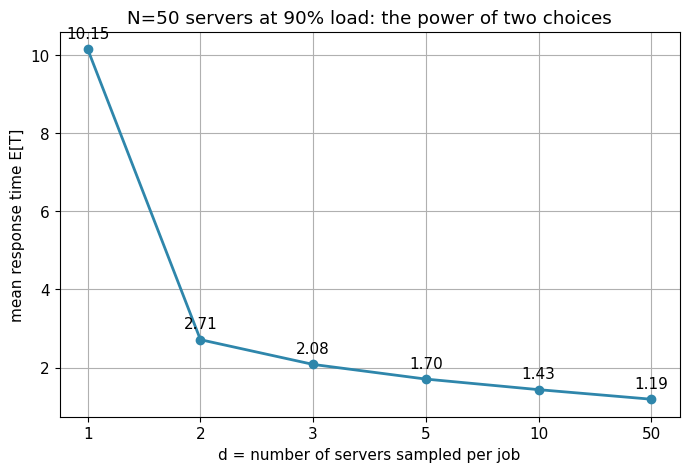

d=1 (random):           E[T] = 10.15
d=2 (two choices):      E[T] = 2.71   (3.7x better than random)
d=50 (full JSQ):        E[T] = 1.19
gap closed by d=2: 83% of the way from random to full JSQ


In [2]:
N, RHO = 50, 0.9
ds = [1, 2, 3, 5, 10, N]
et = [power_of_d(N, d, RHO) for d in ds]

fig, ax = plt.subplots()
ax.plot([str(d) for d in ds], et, "o-", color="#2e86ab", lw=2)
for d, y in zip(ds, et):
    ax.annotate(f"{y:.2f}", (str(d), y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_xlabel("d = number of servers sampled per job")
ax.set_ylabel("mean response time E[T]")
ax.set_title(f"N={N} servers at {RHO:.0%} load: the power of two choices")
plt.show()

print(f"d=1 (random):           E[T] = {et[0]:.2f}")
print(f"d=2 (two choices):      E[T] = {et[1]:.2f}   ({et[0]/et[1]:.1f}x better than random)")
print(f"d={N} (full JSQ):        E[T] = {et[-1]:.2f}")
print(f"gap closed by d=2: {(et[0]-et[1])/(et[0]-et[-1])*100:.0f}% of the way from random to full JSQ")


**The insight.** Going from `d=1` to `d=2` cuts response time by ~4x at this load — a single
extra random probe closes most of the distance to full join-the-shortest-queue, which needs to poll
all 50 servers. Adding more choices (`d=3,5,...`) helps only a little more: **diminishing returns
after two**. Theory explains it: with `d=2` the fraction of servers with a long queue decays
*doubly* exponentially in the queue length, versus only geometrically for `d=1`.

## Why this shaped modern systems

- **Load balancers.** "Two random choices" / "JSQ(2)" / "power of d" is the backbone of scalable
  dispatchers (Nginx, HAProxy variants, distributed schedulers) precisely because it avoids global
  coordination while staying close to optimal.
- **Hashing with two choices.** The same result underpins low-collision hash tables and cache
  placement ("2-choice hashing").
- The lesson generalizes: **a tiny amount of comparison beats none**, and you rarely need global
  information to get near-optimal load balance.

## Takeaways

- **Power of two choices**: sampling 2 servers and taking the shorter is dramatically better than 1
  and nearly as good as sampling all `N`.
- The big win is `d=1 → d=2`; returns diminish quickly after. Cheap, decentralized, near-optimal.